In [44]:
def project_introduction():
    name = "Anjola Olayinka Ayodele"
    programme = "MSc Energy and Sustainable Development"
    student_number = "P2-----"

    message = f'''
    Welcome.

    This project is written by {name}.
    Programme: {programme}.
    Student Number: {student_number}.
    '''

    print(message.strip())


project_introduction()

Welcome.

    This project is written by Anjola Olayinka Ayodele.
    Programme: MSc Energy and Sustainable Development.
    Student Number: P2-----.


As part of my assessment, i have been tasked with a project to analyse a building dataset containing hourly data across energy use, degree days, etc. for a building in Spain  

My objectives for this project includes;
1. Understanding what drives the building energy consumption
2. Normalizing my energy data with degree days
3. Identifying any  pattern or anomalies within my data as regards energy efficiency
4. Develop a prediction model

In [45]:
#Importing my dataset from Google drive using the Drive Mount
from google.colab import drive
drive.mount('/content/drive')
#This line of code assigns to my variable 'file_path' the location of my dataset in my drive
file_path = '/content/drive/MyDrive/Colab Notebooks/DASES Project/db_building_B_variant_01.csv'

#Importing some of the necessary library toolkit i will need to handle the Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [46]:
#my data file will named df for the purpose of this analysis
df = pd.read_csv(file_path)
#A quick view into what my data looks like
df.head()

,DATE,ENERGY,HDD18_3,CDD10,CDD0,PRECTOT,RH2M,T2M_MAX,T2M_MIN,ALLSKY,T2M,HOLIDAY
0,2016-01-01 02:00:00,NaN,11.32,0.0,6.98,10.7,90.97,12.23,1.74,1.7,6.02,1
1,2016-01-01 03:00:00,43.949916,11.32,0.0,6.98,10.7,90.97,12.23,1.74,1.7,6.02,1
2,2016-01-01 04:00:00,47.020880,11.32,0.0,6.98,10.7,90.97,12.23,1.74,1.7,6.02,1
3,2016-01-01 05:00:00,39.699465,11.32,0.0,6.98,10.7,90.97,12.23,1.74,1.7,6.02,1
4,2016-01-01 06:00:00,35.214255,11.32,0.0,6.98,10.7,90.97,12.23,1.74,1.7,6.02,1


In [47]:
#I have used the info to summarize the attributes of my dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43848 entries, 0 to 43847
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   DATE     43848 non-null  object 
 1   ENERGY   43781 non-null  float64
 2   HDD18_3  43848 non-null  float64
 3   CDD10    43848 non-null  float64
 4   CDD0     43848 non-null  float64
 5   PRECTOT  43848 non-null  float64
 6   RH2M     43848 non-null  float64
 7   T2M_MAX  43848 non-null  float64
 8   T2M_MIN  43848 non-null  float64
 9   ALLSKY   43704 non-null  float64
 10  T2M      43848 non-null  float64
 11  HOLIDAY  43848 non-null  int64  
dtypes: float64(10), int64(1), object(1)
memory usage: 4.0+ MB


In [48]:
df.shape

(43848, 12)

In [49]:
#Since my data is an Hourly data, it is important i make sure it is Time Series conscious
#sorting it helps me avoid any data leakage and indexing it will come in handy for resampling and seasonal analysis
df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values(by='DATE')
df.set_index('DATE', inplace=True)

In [50]:
#Checking for missing values in my data set
print("Missing values per column:")
print(df.isna().sum().sort_values(ascending=False))

print("\nENERGY hourly data description:")
print(df["ENERGY"].describe())

Missing values per column:
ALLSKY     144
ENERGY      67
HDD18_3      0
CDD10        0
CDD0         0
RH2M         0
PRECTOT      0
T2M_MAX      0
T2M_MIN      0
T2M          0
HOLIDAY      0
dtype: int64

ENERGY hourly data description:
count    43781.000000
mean        66.623548
std         45.201017
min          1.997776
25%         33.822799
50%         49.776342
75%         92.103293
max        260.006268
Name: ENERGY, dtype: float64


In [51]:
#From the result above, i can deduce that ALLSKY Values are missing
#even in places where energy values are present, i'll sort that first
#Handling ALLSKY missing values should be easier because it follows diurnal and seasonal patterns
#It is smooth and physically continous and solar radiation changes gradually, so a bfill and ffill should fix this preserving daily solar curves.
df['ALLSKY'] = df['ALLSKY'].ffill().bfill()

In [52]:
#Checking for missing values left in my data set
print("Missing values per column:")
print(df.isna().sum().sort_values(ascending=False))

Missing values per column:
ENERGY     67
HDD18_3     0
CDD10       0
CDD0        0
PRECTOT     0
RH2M        0
T2M_MAX     0
T2M_MIN     0
ALLSKY      0
T2M         0
HOLIDAY     0
dtype: int64


In [53]:
#Since i only have 67 missing values out of 43,848 values, it is safe to drop them
#It is 0.0015% of the entire data which can be considered statistically negligible
df_clean = df.dropna().copy()
print("Dataframe shape after dropping missing values:", df_clean.shape)
#Created a new dataframe to handle the clean data

Dataframe shape after dropping missing values: (43781, 11)


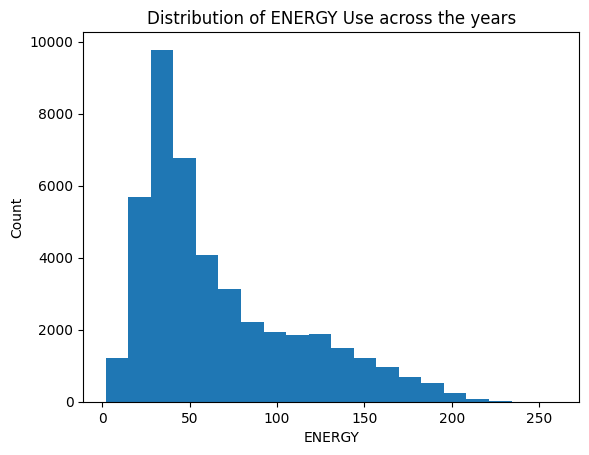

In [54]:
#Histogram distribution in Energy Use across the entire dataset
plt.figure
plt.hist(df_clean['ENERGY'], bins=20)
plt.xlabel('ENERGY')
plt.ylabel('Count')
plt.title('Distribution of ENERGY Use across the years')
plt.show()

In [55]:
#Degree Day Normalisation of my energy dataset
#I decided to use CDD10 because CDD0 does not entirely represent real cooling demand
#Buildings do not cool at zero degrees, It would just overstate the cooling influence and might even overlap with HDD
df_clean['Total_DD'] = df_clean['HDD18_3'] + df_clean['CDD10']
df_clean['Energy_per_DD'] = df_clean['ENERGY'] / df_clean['Total_DD'].replace(0, np.nan)

In [56]:
df_clean[['ENERGY','Energy_per_DD']].describe()
#Based on my deductions, the median is well below the mean (meaning most days perform reasonably efficient)
#the lower quartile (25%) shows the best period of efficient operations and the min suggest that envelope can perform well under some conditions
#However the problem is that the spread is wide (by almost 8 times) and the high maximum is extreme
#the STD is also relatively high compared to the mean and these only suggest that the building controls may be inconsistent
#Or there are variations in the operations of the building like manual overrides, occupancy, etc.
#The Energy per Degree Days is not consistently high so envelope is likely moderate with no evidence of chronic heat loss.

#Basically my conclusion is that the inefficiencies derived from the building's dataset are practically dominated by operational and control factors

,ENERGY,Energy_per_DD
count,43781.000000,43781.000000
mean,66.623548,6.386025
std,45.201017,4.578142
min,1.997776,0.240696
25%,33.822799,3.133677
50%,49.776342,4.756093
75%,92.103293,8.672749
max,260.006268,25.874061


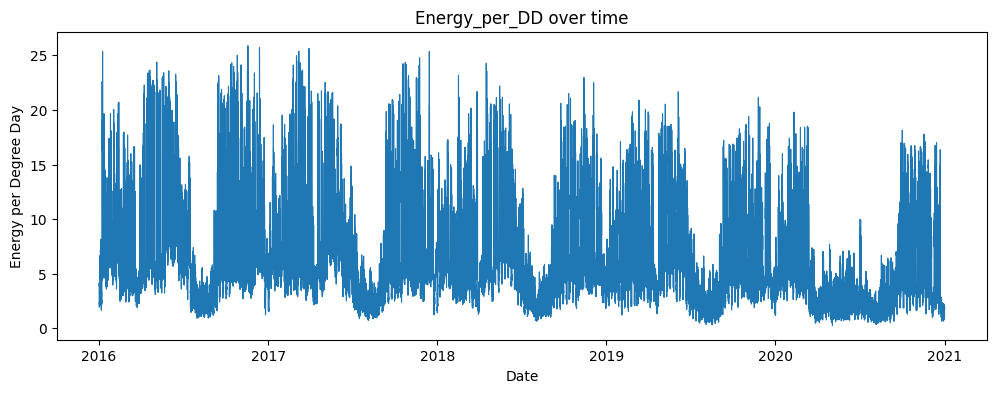

In [57]:
#Note that df.index is my Date and time stamp as set earlier for easier recall
plt.figure(figsize=(12,4))
plt.plot(df_clean.index, df_clean['Energy_per_DD'], linewidth=0.8)
plt.xlabel('Date')
plt.ylabel('Energy per Degree Day')
plt.title('Energy_per_DD over time')
plt.show()

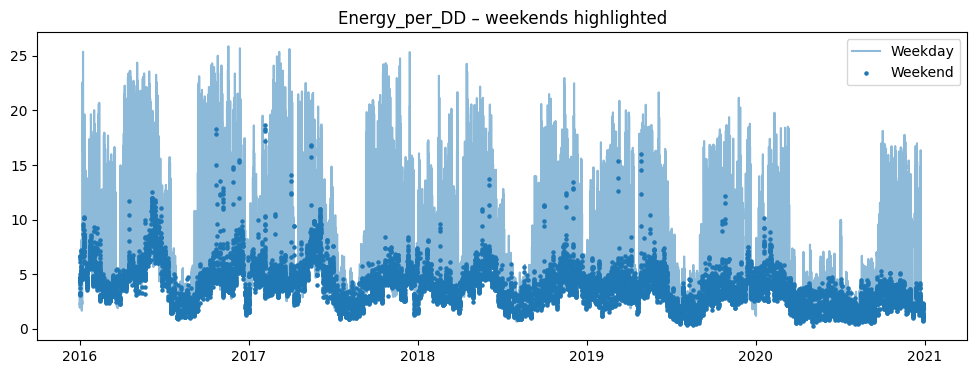

In [58]:
#A plot to showcase the historical energy use on weekends compared to weekdays
df_clean['is_weekend'] = df_clean.index.weekday >= 5
df_clean['is_weekend'] = df_clean['is_weekend'].astype(int)

plt.figure(figsize=(12,4))
plt.plot(
    df_clean.loc[df_clean['is_weekend'] == 0].index,
    df_clean.loc[df_clean['is_weekend'] == 0, 'Energy_per_DD'],
    alpha=0.5,
    label='Weekday'
)
plt.scatter(
    df_clean.loc[df_clean['is_weekend'] == 1].index,
    df_clean.loc[df_clean['is_weekend'] == 1, 'Energy_per_DD'],
    s=5,
    label='Weekend'
)
plt.legend()
plt.title('Energy_per_DD – weekends highlighted')
plt.show()
#There's relatively very few high points in the weekend meaning the building's scheduling is decent

Night Average Use: 4.626117898061331
Day Average Use: 7.266641263524749
Night/Day ratio: 0.6366239546298164


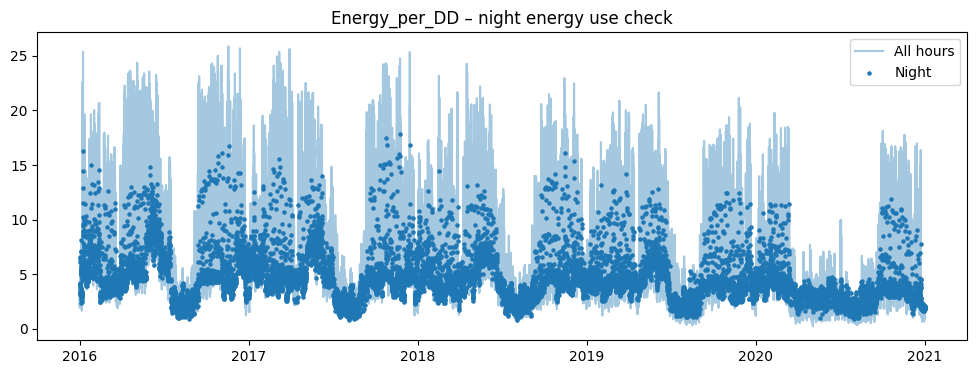

In [59]:
#checking out the night energy use of the building
df_clean['hour'] = df_clean.index.hour

#to check for night energy use
night = df_clean[(df_clean['hour'] >= 22) | (df_clean['hour'] <= 5)].copy()
day = df_clean[(df_clean['hour'] >= 6) & (df_clean['hour'] <= 21)].copy()

'''the | stands for 'or' in my code, Pandas library can only accepts that
for my boolean element comparison'''

#Average energy use across day and night
night_mean = night['Energy_per_DD'].mean()
day_mean = day['Energy_per_DD'].mean()

print("Night Average Use:", night_mean)
print("Day Average Use:", day_mean)
print("Night/Day ratio:", night_mean / day_mean)

plt.figure(figsize=(12,4))
plt.plot(df_clean.index, df_clean['Energy_per_DD'], alpha=0.4, label='All hours')
plt.scatter(night.index, night['Energy_per_DD'], s=5, label='Night')
plt.legend()
plt.title('Energy_per_DD – night energy use check')
plt.show()

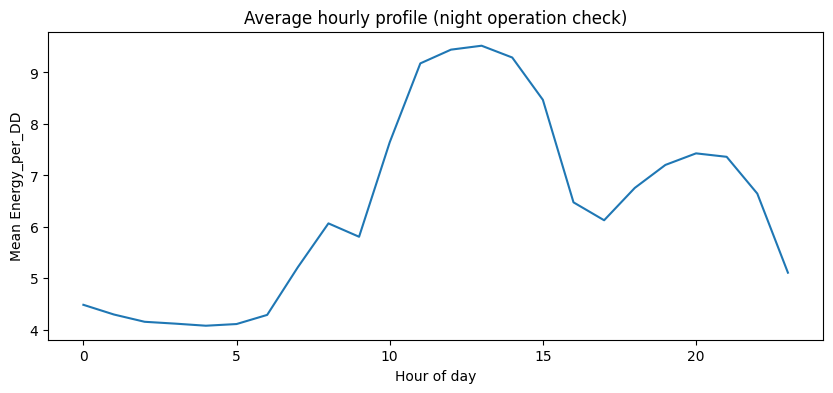

In [60]:
#A better visualisation of the hourly profile for night operations
hour_profile = df_clean.groupby('hour')['Energy_per_DD'].mean()

plt.figure(figsize=(10,4))
plt.plot(hour_profile.index, hour_profile.values)
plt.xlabel("Hour of day")
plt.ylabel("Mean Energy_per_DD")
plt.title("Average hourly profile (night operation check)")
plt.show()


In [61]:
#I want to figure out which month has the peak consumptions across the years
#And is it consistent over the years
df_clean['month'] = df_clean.index.month
df_clean['year'] = df_clean.index.year
#creating a new dataframe for my monthly and yearly data with average energy use
monthly_yearly_energy = (df_clean.groupby(['year', 'month'])['ENERGY'].mean().reset_index())
#Identifying the peak months within the new DataFrame
peak_months = (monthly_yearly_energy.loc[monthly_yearly_energy.groupby('year')['ENERGY'].idxmax()])

In [62]:
peak_months
#Peak consumption consistently occur in Winter Month particularly in January
#The building is responding to harsh weather in this month and not necessarily bad
#The peak has also consistently dropped over the years
#However, its unclear if the peak demand in 2021 is very low due to Post Covid 19 measures

,year,month,ENERGY
10,2016,11,99.584334
12,2017,1,103.387266
24,2018,1,95.773128
36,2019,1,86.208521
48,2020,1,81.416053
60,2021,1,26.817050


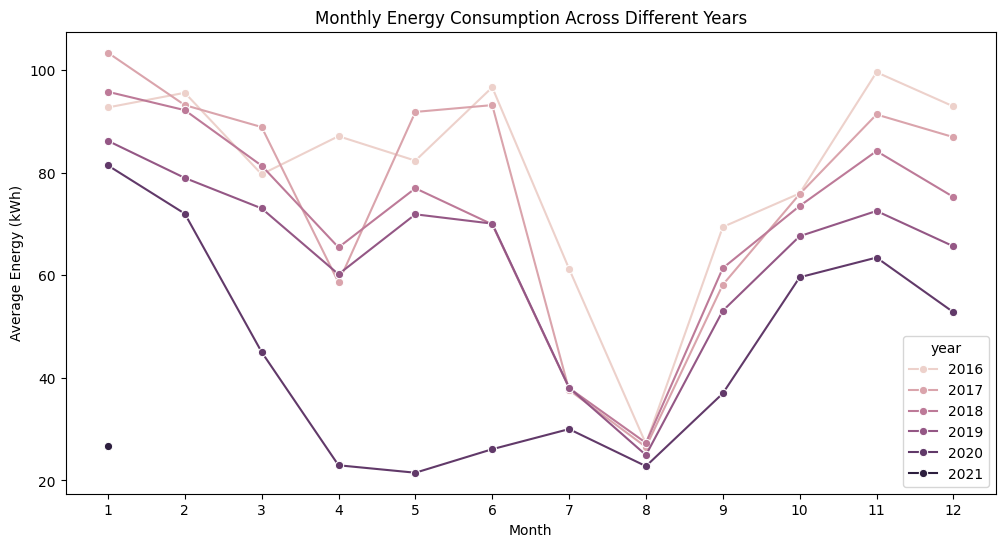

In [63]:
#A line plot to better visualize the average peak monthly demand over the years
plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_yearly_energy, x='month', y='ENERGY',
    hue='year', marker='o')
plt.xticks(range(1,13)) #To capture 12 Months in a year
plt.xlabel('Month')
plt.ylabel('Average Energy (kWh)')
plt.title('Monthly Energy Consumption Across Different Years')
plt.show()

In [64]:
#Now i want to test this new knowlewdge against the normalised version of my data in Degree Days
monthly_yearly_norm = (df_clean.groupby(['year', 'month'])['Energy_per_DD'].mean().reset_index())
peak_norm_months = (monthly_yearly_norm.loc[
    monthly_yearly_norm.groupby('year')['Energy_per_DD'].idxmax()])

peak_norm_months
#Now that the effect of weather has been normalised using DD
#It clearly shows that the building is less efficient per DD in months like May and June which are relatively warmer.
#This could be due to any number of reasons (poor control, late reaction to seasonal change, baseload dominance, etc.)
#The question is what happened in those months ?

,year,month,Energy_per_DD
5,2016,6,10.095415
16,2017,5,10.193960
28,2018,5,9.157619
40,2019,5,8.512012
49,2020,2,7.505563
60,2021,1,1.790190


In [65]:
#because energy demand can be strongly diurnal, I am creating an encoded hourly cycle
df_clean['hour_sin'] = np.sin(2 * np.pi * df_clean['hour'] / 24)
df_clean['hour_cos'] = np.cos(2 * np.pi * df_clean['hour'] / 24)

#The same goes for Monthly data as well
df_clean['month_sin'] = np.sin(2*np.pi*df_clean['month']/12)
df_clean['month_cos'] = np.cos(2*np.pi*df_clean['month']/12)


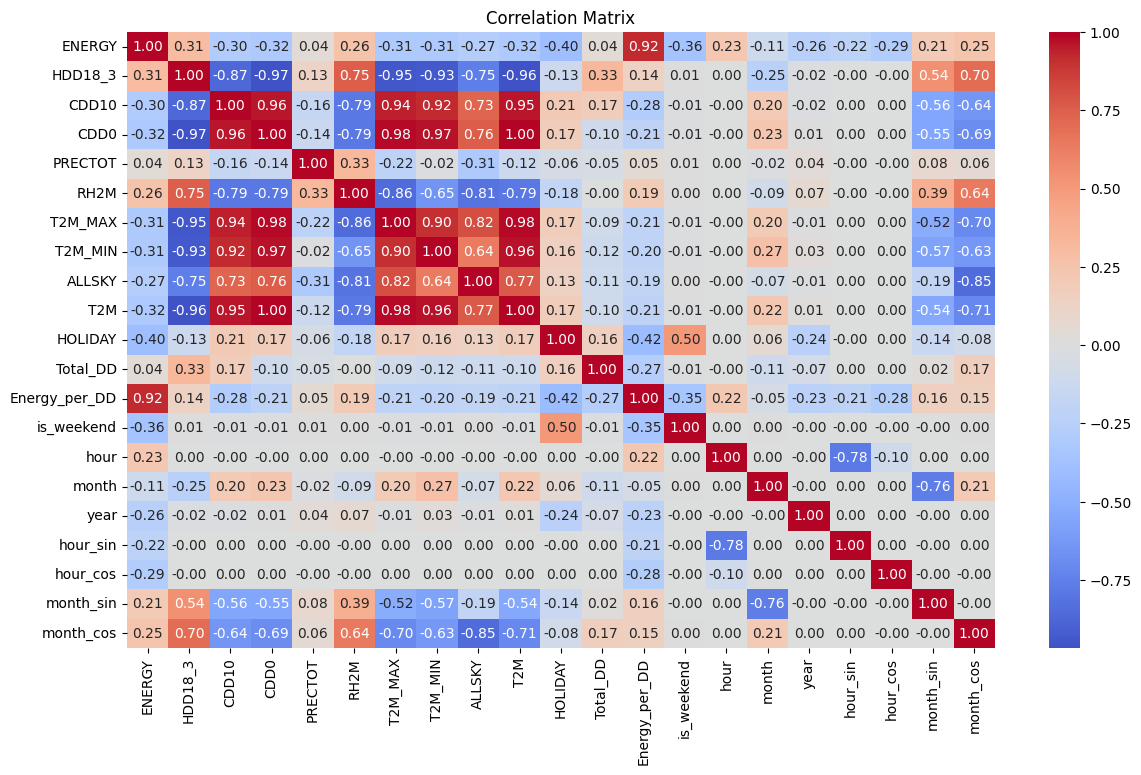

In [66]:
'''Over to a quick Correlation Chart to visualise the interrelationships
of dataset particularly between energy use and degree days or holiday'''
plt.figure(figsize=(14,8))
sns.heatmap(df_clean.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

Now i want to create my regression models to try to predict energy use and then a secondary model to understand the energy efficiency better.

The raw energy consumption data 'ENERGY' will be used as the primary response variable to preserve what is really happening in real life, while energy normalised by degree days 'Energy per DD' will be explored to assess weather-adjusted efficiency.

I feel so pumped, Anjolaolorun you've got this !!!!

In [67]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
#Creating a linear and random forest prediction model
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

#dropping features that can lead to my model cheating
X = df_clean.drop(['ENERGY', 'Total_DD', 'T2M_MIN', 'CDD0', 'Energy_per_DD',
                   'month', 'hour'], axis=1, errors="ignore")
#creating a raw energy value variable
y_raw = df_clean['ENERGY']

#i also want to create a normalized target variable for energy per dd model

eps = 1e-6  # tiny value to avoid zero division

if "Total_DD" in df_clean.columns:
    dd = df_clean["Total_DD"].astype(float)
else:
    # fallback if there is only HDD/CDD columns
    dd = df_clean["HDD18_3"].astype(float) + df_clean["CDD10"].astype(float)

y_per_dd = df_clean["ENERGY"] / (dd + eps)

# This removes rows where degree days are basically zero
#The  extreme ratio outlier
mask = dd > 0.1
x_dd = X.loc[mask].copy()
y_dd = y_per_dd.loc[mask].copy()

#final raw energy variables for the model
x_raw = X.copy()
y_raw = y_raw.copy()


In [68]:
#Splitting my dataset for training
#this one for raw Energy
#I included shuffle=false because if it is true, then my time order won't be preserved
#For example, the model could be seeing tomorrow while learning yesterday
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(x_raw, y_raw, test_size=0.2, shuffle = False )
#this for Energy per DD
#For the normalised energy target, it doesn't really matter because my plan is to predict efficiency
#and normalisation using degree days helps me with the comparison neutralising any confusion concerning weather and operations link to energy use
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(x_dd, y_dd, test_size=0.2)

In [69]:
#I created a reusable function to efficiently evaluate any model
def evaluate_model(model, X_train, y_train, X_test, y_test, name="Model"):
    model.fit(X_train, y_train)

    pred_train = model.predict(X_train)
    pred_test  = model.predict(X_test)

    results = {
        "model": name,
        "train_r2": r2_score(y_train, pred_train),
        "test_r2": r2_score(y_test, pred_test),
        "train_mae": mean_absolute_error(y_train, pred_train),
        "test_mae": mean_absolute_error(y_test, pred_test),
        "train_mse": mean_squared_error(y_train, pred_train),
        "test_mse": mean_squared_error(y_test, pred_test),
    }
    return results


In [70]:
#Linear Regression Model
lr = LinearRegression()

raw_lr_results = evaluate_model(lr, X_train_r, y_train_r, X_test_r, y_test_r, "LR (raw ENERGY)")

print(raw_lr_results)

{'model': 'LR (raw ENERGY)', 'train_r2': 0.5736433348077581, 'test_r2': -0.9444431263866437, 'train_mae': 24.81940584595448, 'test_mae': 41.064809778325014, 'train_mse': 894.9398408456585, 'test_mse': 2351.7895218324884}


In [ ]:
#RandomForest Regression Model
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

raw_rf_results = evaluate_model(rf, X_train_r, y_train_r, X_test_r, y_test_r, "RF (raw ENERGY)")
print(raw_rf_results)

In [ ]:
#Both models for energy efficiency prediction using energy per degree days
dd_lr_results = evaluate_model(lr, X_train_d, y_train_d, X_test_d, y_test_d, "LR (ENERGY per DD)")
dd_rf_results = evaluate_model(rf, X_train_d, y_train_d, X_test_d, y_test_d, "RF (ENERGY per DD)")

print(dd_lr_results)
print(dd_rf_results)
#Random Forest Model appears to be doing a better job than linear model


In [ ]:
#created a reusable function fOr my Scatter Plot
def plot_pred(y_true, y_pred, title):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred)
    mn = min(y_true.min(), y_pred.min())
    mx = max(y_true.max(), y_pred.max())
    plt.plot([mn, mx], [mn, mx])
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.show()

In [ ]:
rf.fit(X_train_r, y_train_r)
pred = rf.predict(X_test_r)
plot_pred(y_test_r, pred, "RF: Actual vs Predicted (raw ENERGY)")
#The RF shows the model is doing well in some segment but suddenly went off rail

In [ ]:
rf.fit(X_train_d, y_train_d)
pred = rf.predict(X_test_d)
plot_pred(y_test_d, pred, "RF: Actual vs Predicted (ENERGY per DD)")
#Doing a much better job than raw energy usage

In [ ]:
#Trying to figure out why i have a negative R squared value for raw energy model
print("X dtypes (non-numeric):")
print(x_raw.select_dtypes(exclude=[np.number]).columns)

print("\nAny NaNs in X_raw?", x_raw.isna().any().any())
print("Any NaNs in y_raw?", y_raw.isna().any())


In [ ]:
#Checking if timestamps of the data trained which is set as index matches that of the test data
print("X_raw index equals y_raw index:", x_raw.index.equals(y_raw.index))

In [ ]:
#Trying out a Cross-Validation to better examine why my raw energy model is perfoming poorly
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

cv_r2 = cross_val_score(rf, x_raw, y_raw, cv=tscv, scoring="r2")
cv_mae = -cross_val_score(rf, x_raw, y_raw, cv=tscv, scoring="neg_mean_absolute_error")

print("CV R2:", cv_r2, "mean:", cv_r2.mean())
print("CV MAE:", cv_mae, "mean:", cv_mae.mean())


In [ ]:
#To identify the reasons for the poor performance of the Random Forest Regressor model
#i am investigating the last cross-validation fold data, specifically focusing on the
#'ENERGY' consumption and relevant features like 'T2M' and 'HDD18_3' within specific time period


#To identify the last cross-validation fold,
#I will iterate through the TimeSeriesSplit and store the indices for the last train and test sets.
#Then, I will use these indices to find the corresponding datetime ranges from the original DataFrame's index.

tscv = TimeSeriesSplit(n_splits=5)

# Iterate through the splits to get the last one
for train_index, test_index in tscv.split(x_raw, y_raw):
    last_train_index = train_index
    last_test_index = test_index

# Get the datetime indices for the last fold
last_train_dates = x_raw.index[last_train_index]
last_test_dates = x_raw.index[last_test_index]

print("Last CV Fold - Training Set Time Range:")
print(f"Start Date: {last_train_dates.min()}")
print(f"End Date: {last_train_dates.max()}")
print("\nLast CV Fold - Test Set Time Range:")
print(f"Start Date: {last_test_dates.min()}")
print(f"End Date: {last_test_dates.max()}")

In [ ]:
#A quick visualisation of the 'ENERGY' consumption during the last test set period.
#There seem to be unusual patterns and significant shifts between march and october 2020.
#This could possibly be why the model is struggling
plt.figure(figsize=(15, 6))
plt.plot(y_raw.loc[last_test_dates.min():last_test_dates.max()], label='Actual ENERGY (Last Test Fold)')
plt.title('Actual ENERGY Consumption in the Last Cross-Validation Test Fold')
plt.xlabel('Date')
plt.ylabel('ENERGY (kWh)')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
#Temperature pattern visualisation from the last test
#The temperature significantly increased and yet energy consumption stayed low even at peak temp in August
plt.figure(figsize=(15, 6))
plt.plot(x_raw.loc[last_test_dates.min():last_test_dates.max(), 'T2M'], label='Actual T2M (Last Test Fold)', color='orange')
plt.title('Average Temperature (T2M) in the Last Cross-Validation Test Fold')
plt.xlabel('Date')
plt.ylabel('T2M')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
#Plot of 'HDD18_3' (Heating Degree Days) to observe any unusual heating demand patterns
plt.figure(figsize=(15, 6))
plt.plot(x_raw.loc[last_test_dates.min():last_test_dates.max(), 'HDD18_3'], label='Actual HDD18_3 (Last Test Fold)', color='red')
plt.title('Heating Degree Days (HDD18_3) in the Last Cross-Validation Test Fold')
plt.xlabel('Date')
plt.ylabel('HDD18_3')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
#Plot of 'CDD10' (Cooling Degree Days) to observe any unusual cooling demand patterns
plt.figure(figsize=(15, 6))
plt.plot(x_raw.loc[last_test_dates.min():last_test_dates.max(), 'CDD10'], label='Actual CDD10 (Last Test Fold)', color='green')
plt.title('Cooling Degree Days (CDD10) in the Last Cross-Validation Test Fold')
plt.xlabel('Date')
plt.ylabel('CDD10')
plt.grid(True)
plt.legend()
plt.show()

# KEY FINDINGS

The visualizations of **ENERGY consumption** in the last test fold (March 2020 - January 2021) show a significant and sustained drop in energy usage compared to previous periods. This sharp decline is abnormal compared to normal seasonal or operational variations and likely corresponds to external events that makes it hard for the model to train properly. The timing strongly suggests it could be the impact of the **COVID-19 pandemic**.

The **T2M, HDD18_3, and CDD10** show expected seasonal patterns, they do not exhibit any unusual anomalies that would solely explain such a drastic and prolonged reduction in energy consumption. This indicates that the drop in energy is not primarily weather-driven but rather influenced by changes in building usage and operational patterns due to the pandemic.

In [ ]:
#Created a Summary table for my model results
Modelsummary_df = pd.DataFrame([raw_lr_results, raw_rf_results, dd_lr_results, dd_rf_results])
display(Modelsummary_df)

### Observations on the Prediction Model Performance

From the summary table, I can draw the following observations and conclusions:

1.  **Raw Energy Model**
    *   The Linear Regression model (raw ENERGY) has R square value of -0.94 and Mean Absolute Error of 41.06, indicating a very poor performance, worse than simply predicting the mean, which was further highlighted by the time series cross-validation.

    *   The Random Forest model (raw ENERGY) also has a negative R square value of -1.54 and a Mean Absolute Error of 41.40. While its training metrics are excellent with R square value 0.99, there is a clear sign of overfitting, especially given the severe drop in performance on the test set. This confirms the issues identified during cross-validation, likely due to the data shift caused by the COVID-19 pandemic in the later test period.


 My conclusion is that both models are performing poorly on the raw energy prediction task, particularly in the later, unseen data. The RF model, despite its complexity, is heavily overfitting the training data and failing to generalize it.

2.  **Energy per Degree Day Model (Efficiency)**
    *   The Linear Regression model (ENERGY per DD)shows an R square value of 0.52 and a Mean Absolute Error of 2.51. This is a reasonable performance, suggesting that the linear relationship holds somewhat for the normalized efficiency metric.
    *   The Random Forest model (ENERGY per DD)performs significantly better with an R square value of 0.97 and a Mean Absolute Error of 0.45. The high test_r2 indicates that the RF model explains 97% of the variance in energy efficiency, and the low test Mean Absolute Error suggests highly accurate predictions.

    My Conclusion is that the Random Forest model is much more effective at predicting energy efficiency (normalized by degree days) than the raw energy consumption. This implies that once weather effects are accounted for, the patterns governing operational efficiency are more stable and predictable, and the non-linear capabilities of the Random Forest shine.


To improve the raw energy consumption model, i have to address the data shift by adding pandemic indicators and re-training with more recent data.